## Decision Trees

Decision trees can be used for both classification and regression.  They are similar to if/then statements.

Tree depth: how many questions do we ask until we reach our decision? (denoted by its longest route)

Root node: first decision  
Leaf node: final node of the tree

<img 
  width="500px"
  src="images/Decision-tree-showing-the-risk-of-malignant-effusion-when-medical-history-and-diagnostic.png" /> 

Advantages: 
* easy to interpret
* can use both qualitative and quantitative predictors and responses
* reproducible in clinical workflow
* fast and perform well on large datasets

Disadvantages:
* need an optimal choice at each node; at each step, the algorithm chooses the best result. Choosing the best result at a given step does not ensure an optimal decision when you make it to the leaf node
* prone to over-fitting, especially with deep trees (fix: can set a max depth--this limits variance, but at the expense of bias!)

Here are some linkes with more information about decision trees:
* https://www.datacamp.com/community/tutorials/decision-tree-classification-python
* http://dataaspirant.com/2017/02/01/decision-tree-algorithm-python-with-scikit-learn/
* https://towardsdatascience.com/how-to-visualize-a-decision-tree-from-a-random-forest-in-python-using-scikit-learn-38ad2d75f21c

In [1]:
import pandas as pds
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pydotplus
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import tree
from IPython.display import Image 

import random
## set seed for randomization
random.seed(123)

## Pima Indians Diabetes dataset
We will use the Pima Indians dataset to experiment with decision trees. The Pima are a group of Native Americans living in Arizona. A genetic predisposition allowed this group to survive normally to a diet poor of carbohydrates for years. In the recent years, because of a sudden shift from traditional agricultural crops to processed foods, together with a decline in physical activity, made them develop the highest prevalence of type 2 diabetes and for this reason they have been subject of many studies. 

The dataset can be downloaded here:

https://www.kaggle.com/uciml/pima-indians-diabetes-database#diabetes.csv

but I have already downloaded a local copy named `diabetes.csv`.

The dataset includes data from 768 women. The columns are defined as follows:

* `Pregnancies`: Number of times pregnant
* `Glucose`: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
* `BloodPressure`: Diastolic blood pressure (mm Hg)
* `SkinThickness`: Triceps skin fold thickness (mm)
* `Insulin`: 2-Hour serum insulin (mu U/ml)
* `BMI`: Body mass index (weight in kg/(height in m)^2)
* `DiabetesPedigreeFunction`: The output of the pedigree function that provides measure of genetic influence and gives us an idea of the hereditary risk one might have with the onset of diabetes mellitus
* `Age`: Age (years)
* `Outcome`: Class variable (0 or 1) 268 of 768 are 1 (positive), the others are 0 (negative)

In [2]:
## load Pima Indians Diabetes dataset (downloaded May 14, 2019; N=768)
df = pds.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Inspecting the data
Before we analyze the data, we need to first inspect its values. Two handy methods are Pandas' `describe()` and `corr()` methods.

The `describe()` provides a statistical summary of values. 

Execute the code cell to see this for the dataframe `df`.

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Examining the data we see that some columns have a **min** of `0`. Sometimes this is fine (e.g., pregnancies), but it doesn't make much sense for someone to have a skin thickness or blood pressure of `0`. This records are most likely invalid, and we will need to deal them (later).

The `corr()` method outputs a matrix of values (i.e., a correlation matrix) measuring the correlation between the variables (i.e., columns) in the dataframe.

In [5]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In the above matrix, we see that some values are highly correlated. For example, `Age` is highly correlated (0.544341) with `Pregancies`.

## Digression
The correlation matrix is bit hard to read (at least it is for me). However, Pandas provides some nice functionality display the matrix as a heatmap.

In [6]:
## it can be helpful to color code the matrix
## ".style.format{:.2}" formats the output to use 2 significant digits
## try showing the correlation matrix w/o formating to see difference
df.corr(method='pearson').style.format("{:.2}")\
        .background_gradient(cmap=plt.get_cmap('coolwarm'), axis=1)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.0,0.13,0.14,-0.082,-0.074,0.018,-0.034,0.54,0.22
Glucose,0.13,1.0,0.15,0.057,0.33,0.22,0.14,0.26,0.47
BloodPressure,0.14,0.15,1.0,0.21,0.089,0.28,0.041,0.24,0.065
SkinThickness,-0.082,0.057,0.21,1.0,0.44,0.39,0.18,-0.11,0.075
Insulin,-0.074,0.33,0.089,0.44,1.0,0.2,0.19,-0.042,0.13
BMI,0.018,0.22,0.28,0.39,0.2,1.0,0.14,0.036,0.29
DiabetesPedigreeFunction,-0.034,0.14,0.041,0.18,0.19,0.14,1.0,0.034,0.17
Age,0.54,0.26,0.24,-0.11,-0.042,0.036,0.034,1.0,0.24
Outcome,0.22,0.47,0.065,0.075,0.13,0.29,0.17,0.24,1.0


Now the high correlation between `Age` and `Pregnancies` is easy to spot.
The `.style.format{:.2}` formats the output to use 2 significant digits, and the color map (i.e., get_cmap) is specified as "coolwarm". A number of other color maps are possible, bit I'll leave it to you to investigate this :)

Another option for displaying the correlation matrix is to use Seaborn's `heatmap` function. This allows you to control a number of display options to make the figure look better. I also like to add a color bar to show how colors map to values.

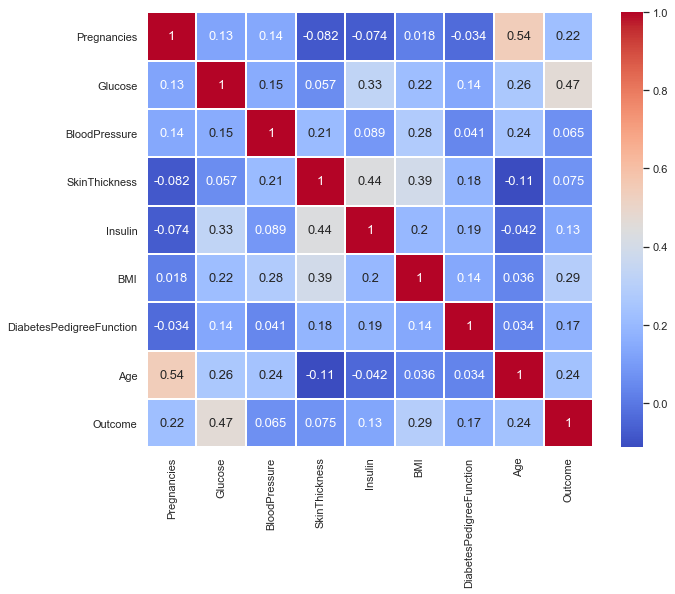

In [7]:
# specify Jupyter to use inline; see: https://ipython.readthedocs.io/en/stable/interactive/plotting.html
%matplotlib inline 
sns.set() # use seaborn's default colors
plt.figure(figsize = (10,8)) # this sets width and height of the figure

corr = df.corr() # store correlation matrix in corr

## display the heatmap; I set a nubmer of options (such as linewidths and size) to adjust the look of the heatmap.
## 'RdBu_r' & 'BrBG' are other good diverging colormaps
ax = sns.heatmap(corr, annot=True, cmap="coolwarm", annot_kws={"size":13}, linewidths=1.0) 


This heatmap still seems a little too busy for me. Also, if you notice, the correlation values appear in the both upper-right and lower-left portions of the heatmap. So, we can cut out the upper-right triangle by creating a mask to cover it.

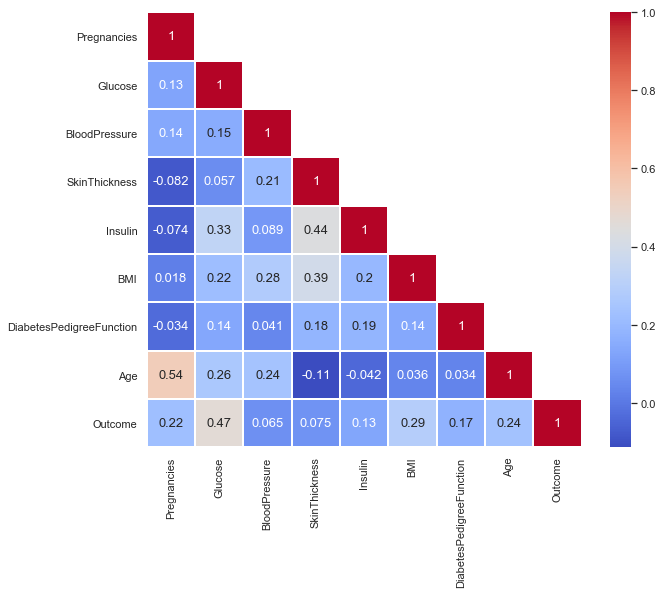

In [8]:
%matplotlib inline 
sns.set()
plt.figure(figsize = (10,8)) 
corr = df.corr()

## creat a mask to cover the upper-right portion of the heatmap
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask, k=1)] = True

## show heatmap with mask
with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, cmap="coolwarm", square=True, 
                     mask=mask, annot_kws={"size":13}, linewidths=1.0)

Now we can quickly scan the figure to see the correlation between the variables.

To make it easier to display a correlation matrix, I will define a function that I can call later.

In [9]:
def corr_matrix(df, figure_size=(10,8), color_map="coolwarm", font_size=13):
    sns.set()
    plt.figure(figsize = figure_size) 
    corr = df.corr()

    ## creat a mask to cover the upper-right portion of the heatmap
    mask = np.zeros_like(corr, dtype=np.bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    ## show heatmap with mask
    with sns.axes_style("white"):
        ax = sns.heatmap(corr, annot=True, cmap=color_map, square=True, 
                         mask=mask, annot_kws={"size":font_size}, linewidths=1.0)

## Histograms
To see the distributions of data in our dataset, we can use Pandas' `hist()` method. This another nice way to quickly get a sense of the shape of the data. For instance, it allows us to easily see the high number of `0` values for some variables, such as `SkinThickness`.

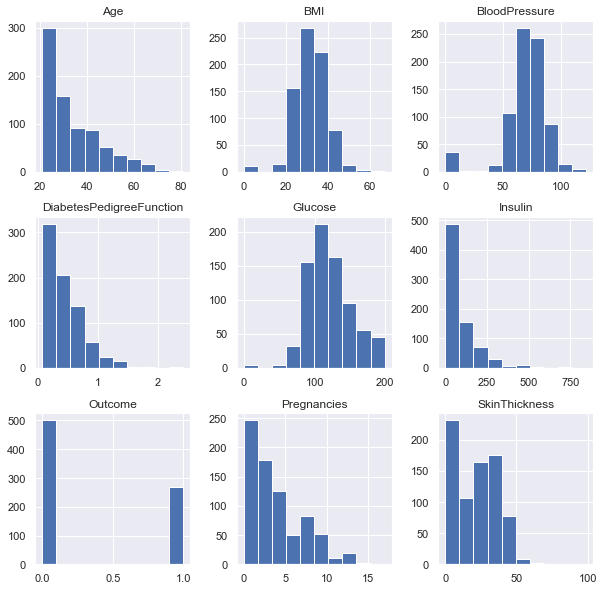

In [10]:
## show histograms of how the data is distributed
df.hist(figsize=(10,10))
plt.show() # this is used to hide unwanted output; try uncommenting to see the behavior

## What to do about invalid data?
Above, we noticed that our data values that do not make sense. Specifically, we saw `0` values for:
`Glucose`
`BloodPressure`
`SkinThickness`
`Insulin`
`BMI`
`Age`

Non-sense values like this are common in medical informatics data. In order for our machine algorithm to make accurate predictions, we need to deal with them. Some ways to do this are:
* Use a different model or tool (rpart works with random forest with missing values)
* Impute missing values (missForest, mice, rfImpute)
* Predict them seperately
* Delete all missing/invalid value cases

For this module will simply delete the invalid cases.

In the code cell below, I define a `valid_value` function that returns `False` if any of the above variables has a value of `0`.

The output of this function is then used to filter the dataframe `df` to only include those rows where a `True` value was returned:
```python
df[df.apply(lambda row: valid_value(row), axis=1)]
```
The filtered rows are then stored in a new variable named `df_pima`.

In [11]:
## funciton to determine of a row has an invalid value
def valid_value(row):
    if 0 == row['Glucose'] or \
       0 == row['BloodPressure'] or \
       0 == row['SkinThickness'] or \
       0 == row['Insulin'] or \
       0 == row['BMI'] or \
       0 == row['Age']:
        return False
    else:
        return True

## create dataframe with only valid rows
df_pima = df[df.apply(lambda row: valid_value(row), axis=1)]
df_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


As you can see from the above output, the indexes (i.e., the left-most column) has gaps in the numbering. This is because the original indexes were saved in filtered dataframe (`df_pima`).

You can also compare the number of rows between the original and filtered dataframes.

In [12]:
print(f"length of original dataframe:{len(df)}")
print(f"length of filtered dataframe:{len(df_pima)}")

length of original dataframe:768
length of filtered dataframe:392


You can use the `describe()` and `hist()` methods to verify that the variables of concern no longer contain `0`s.

In [13]:
df_pima.describe().loc['min']

Pregnancies                  0.000
Glucose                     56.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.085
Age                         21.000
Outcome                      0.000
Name: min, dtype: float64

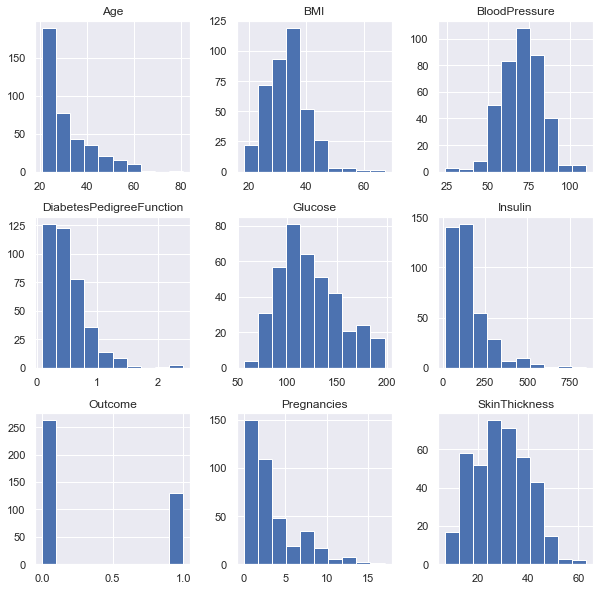

In [14]:
df_pima.hist(figsize=(10,10))
plt.show()

Finally, we can use the `corr_matrix` defined above to see how strongly variables are correlated.

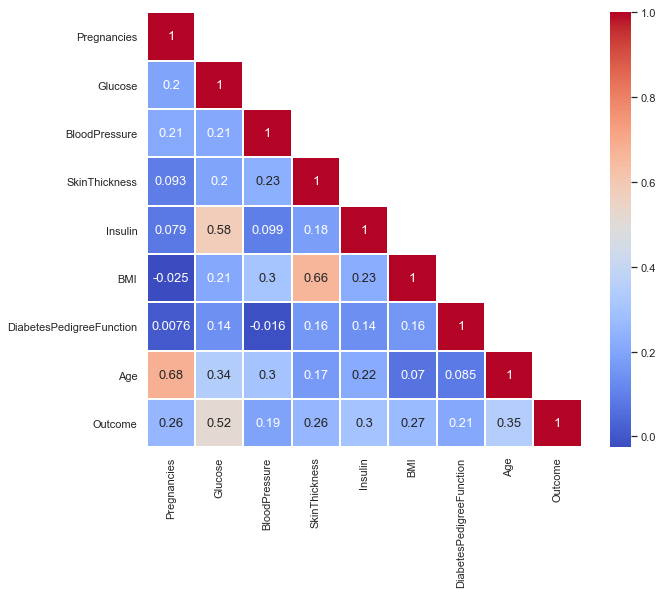

In [15]:
corr_matrix(df_pima)

## Implementing decision trees
Now that the data has been inspected and cleaned, we can implement a decisio tree.

For this will will use scikit-learn's `DecisionTreeClassifier()`:
* https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

To use this funcition, we need to define a dataset that contains the features used to build our decision tree, and a dataset that contains the target (or outcome) we are trying to coming to arrive at decision about.

By convention, scikit-learn often refers to the feature dataset as `X` and the target dataset as `y`.



In [16]:
#split dataset in features and target variable
feature_cols = \
    ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose',
     'BloodPressure','DiabetesPedigreeFunction', 'SkinThickness']

X = df_pima[feature_cols]
y = df_pima['Outcome']

In order to build the decision tree, we will need to split the dataset into a training set and a test set. The training set that is used to build the tree, and the test set that is used to evaluate it.

This is necessary for both the feature dataset (`X`) and the target/outcome dataset (`y`).

Scikit-learn's `train_test_split()` funciton allows us to easily do this.

In [17]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test


After creating the training and test datasets, we call the `DecisionTreeClassifier()` function  to build the decision tree. 

The hierarchical structure of a decision tree leads us to the final outcome by traversing through the nodes of the tree. Each node consists of an attribute or feature which is further split into more nodes as we move down the tree.

The Gini index (or Gini impurity) is the default method used determine the features to used at each node. Briefly, Gini index measures the degree or probability of a particular variable being wrongly classified when it is randomly chosen. If all the elements belong to a single class, then it can be called pure. The degree of Gini index varies between 0 and 1, where 0 denotes that all elements belong to a certain class or if there exists only one class, and 1 denotes that the elements are randomly distributed across various classes. A Gini Index of 0.5 denotes equally distributed elements into some classes.

More information about the Gini index and other methods for feature splitting is found here:
* https://blog.quantinsti.com/gini-index/
* https://medium.com/deep-math-machine-learning-ai/chapter-4-decision-trees-algorithms-b93975f7a1f1

In the below code, I create a decision tree named `dtree`. After the tree is created, the `fit` method is called to train (i.e., build) the tree using the traing data `X_train`.

In [18]:
# create decision tree classifer object
dtree = DecisionTreeClassifier()

# train decision tree classifer
dtree = dtree.fit(X_train, y_train)


## Visualizing the tree
With the decision tree built, we can visualize the nodes. For this will use scikit-learn's `export_graphviz()` funciton:
* https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

The generated figure is difficult read, but if you **squint** you may be able to make out the features and values used to make the splits. Importantly, the Gini index of all leaf nodes is `0`.

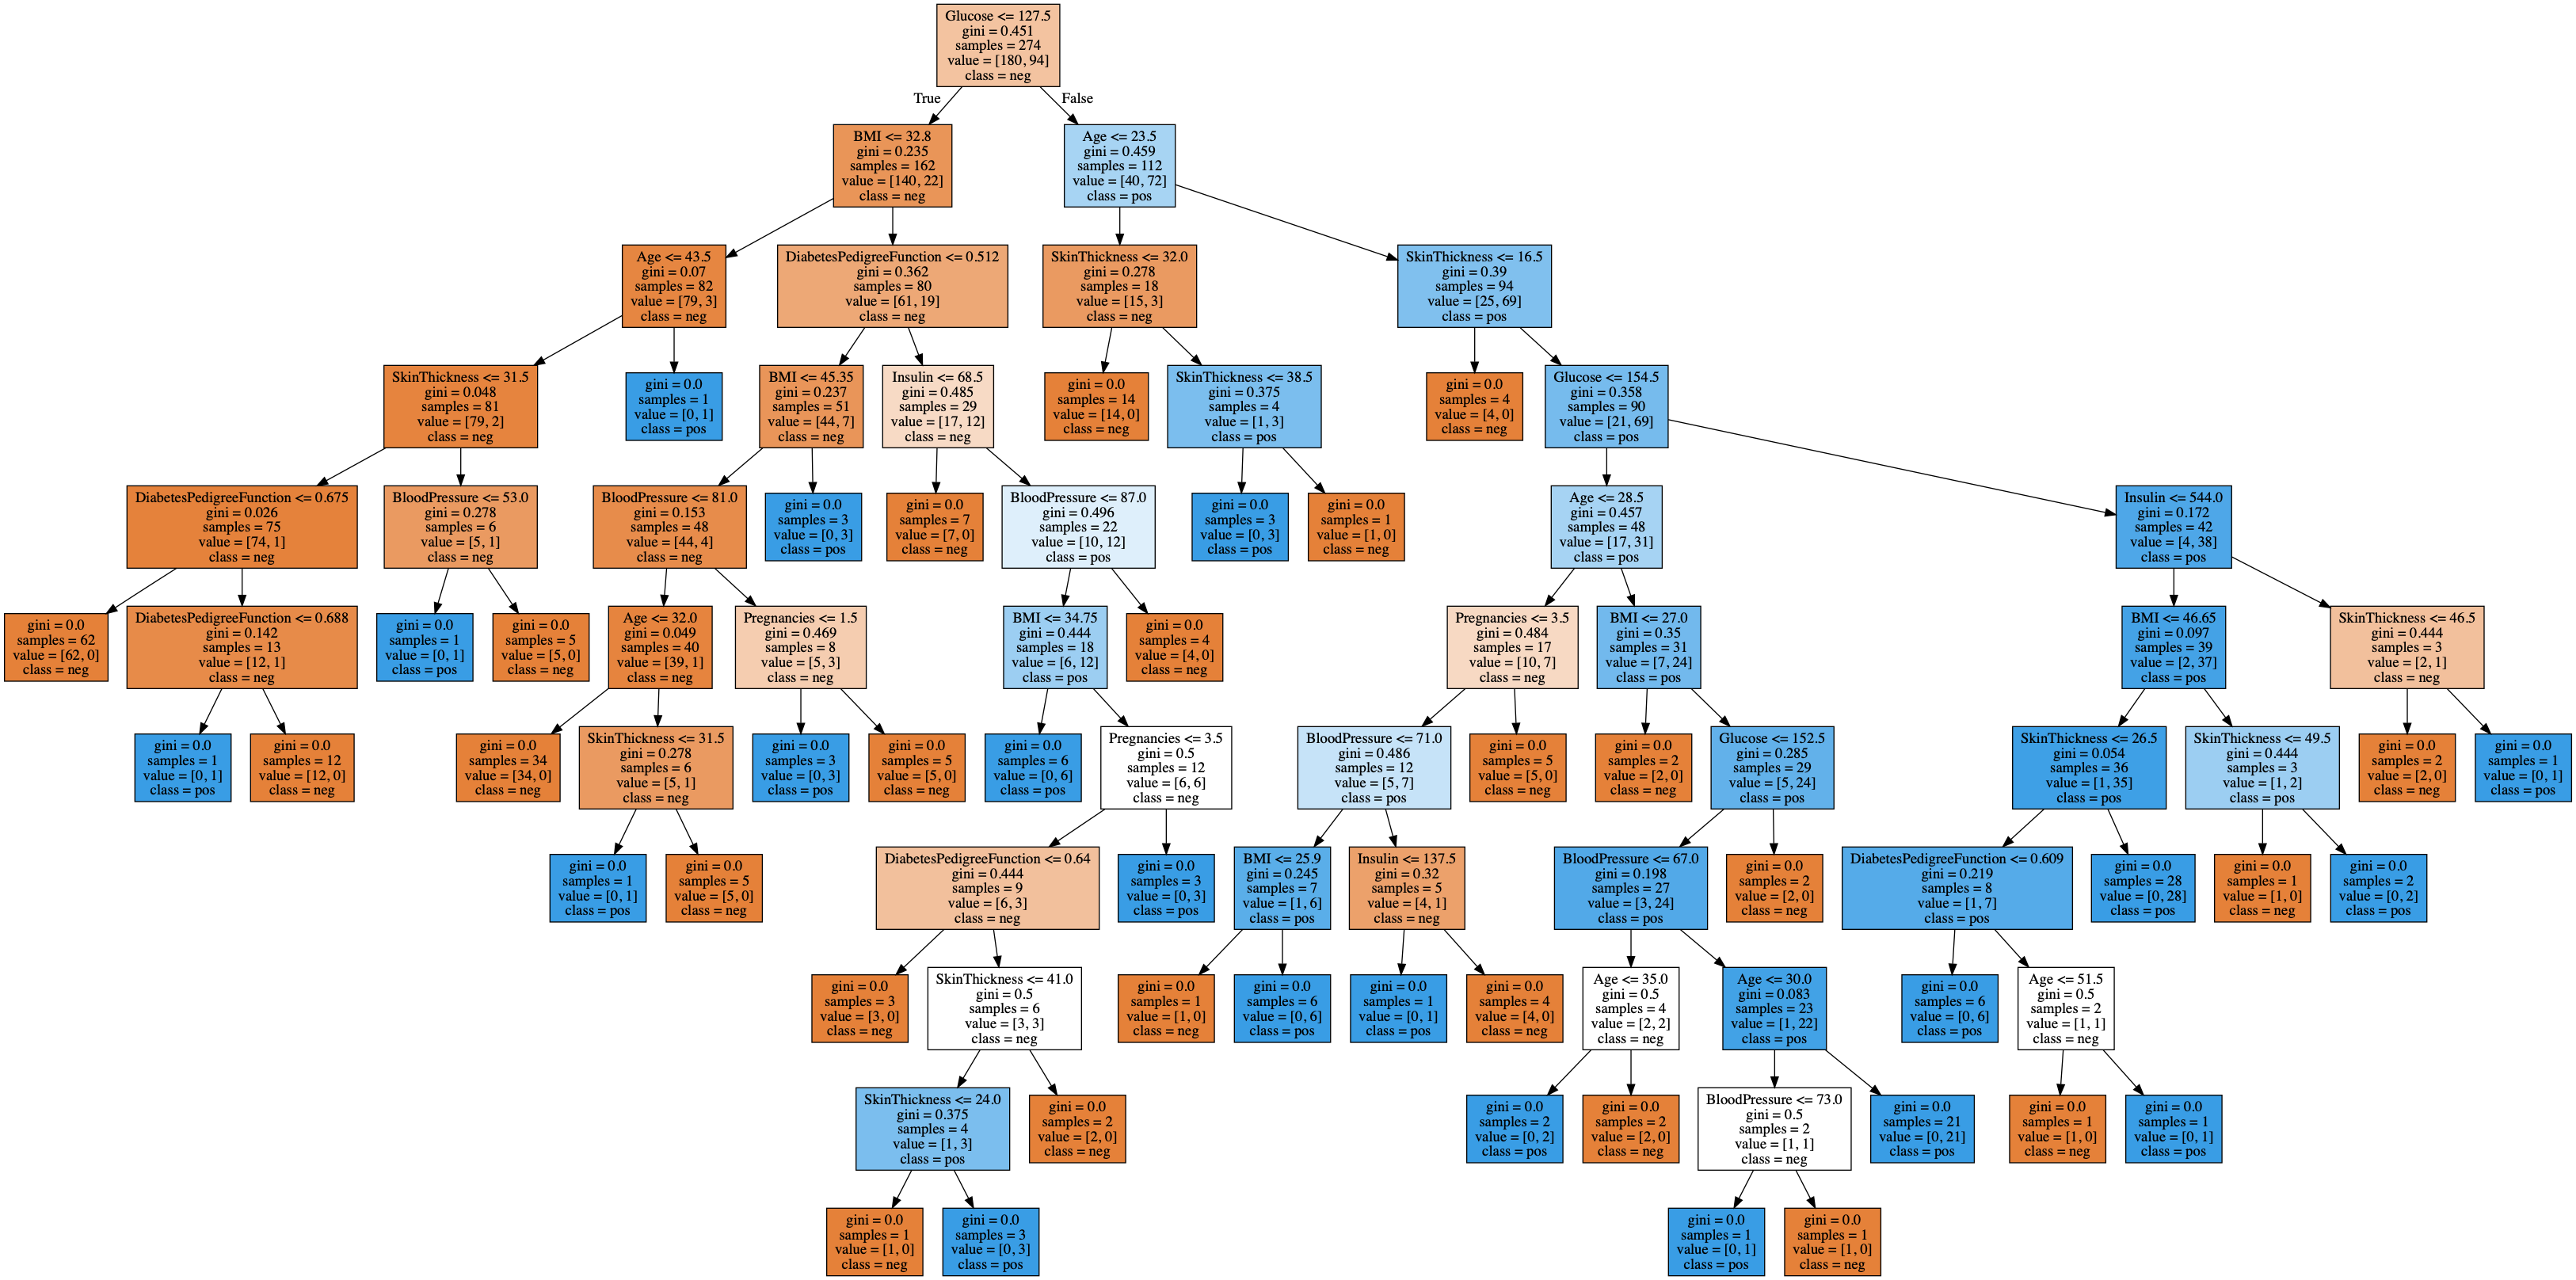

In [19]:
%matplotlib inline
from sklearn.externals.six import StringIO 
from IPython.display import Image, display

# export the tree as dot
dot_data = tree.export_graphviz(dtree, out_file=None, filled=True, 
                                feature_names=feature_cols, class_names=['neg','pos'])
# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)  

# Show graph
Image(graph.create_png())

## Tree pruning
A disadvantage of decision trees is that they are prone to overfitting as they grow larger and more complex. One way to address this is to prune the tree by limiting the maximum depth of the tree. Another way is use a random forest classifier (discussed below).

Below I define a decision tree with a maximum depth of `4`, and for convenience I use the labels `neg` and `pos` instead of `0` and `1`. 

It also makes the tree much easier to read :)

In [20]:
# prune the tree to a max depth of 4
dtree_pruned = DecisionTreeClassifier(max_depth=4) # default criterion="gini"

# Train Decision Tree Classifer
dtree_pruned = dtree_pruned.fit(X_train,y_train)

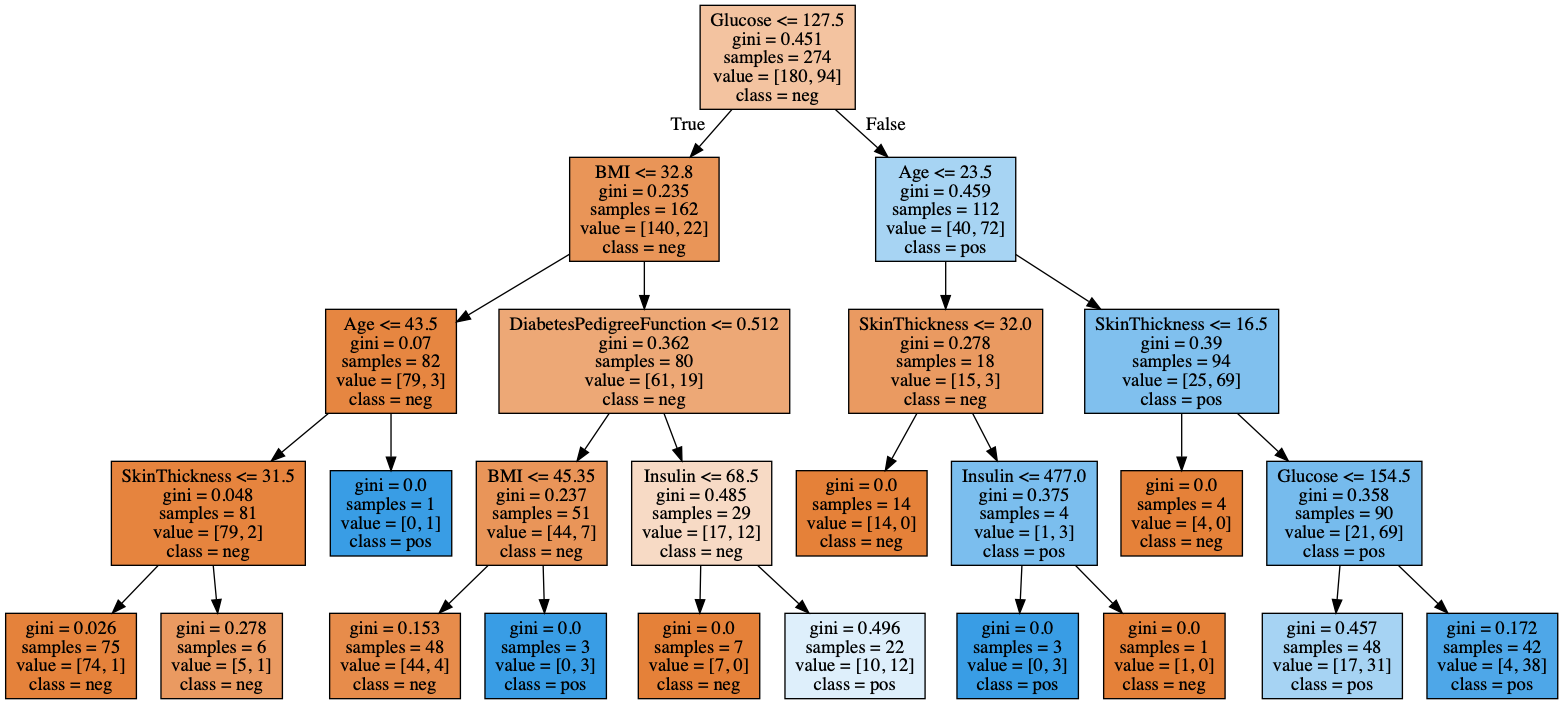

In [21]:
## visualize the pruned tree
dot_data = \
    tree.export_graphviz(dtree_pruned, out_file=None, filled=True, 
                         feature_names=feature_cols, class_names=['neg','pos'])

# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)  

# Show graph
Image(graph.create_png())

## Evaluating output
We need to now evaluate the decision trees (pruned and full). For this, we will use the decision tree `predict()` method. The output of this method will be stored in the variables `y_pred_tree` and `y_pred_pruned`. These (predicted) variables will assedd using a confusion matrix.

### Confusion matrix
<img width="400px" src="images/confusion_matrix3.png" />

A confusion matrix is a summary of prediction results on a classification problem.
The number of correct and incorrect predictions are summarized with count values and broken down by each class. This is the key to the confusion matrix.
The confusion matrix shows the ways in which your classification model is confused when it makes predictions.
It gives us insight not only into the errors being made by a classifier but more importantly the types of errors that are being made. (https://www.geeksforgeeks.org/confusion-matrix-machine-learning/)

**Definition of the Terms**:
* Positive (P) : Observation is positive (for example: is an apple).
* Negative (N) : Observation is not positive (for example: is not an apple).
* True Positive (TP) : Observation is positive, and is predicted to be positive.
* False Negative (FN) : Observation is positive, but is predicted negative.
* True Negative (TN) : Observation is negative, and is predicted to be negative.
* False Positive (FP) : Observation is negative, but is predicted positive.

Using the confusion matrix, we can define the following metrics of evaluation.

**Accuracy:**
* (TP + TN) / (TP + TN + FP + FN)
* Accuracy is the ratio of correct predictions to total predictions made. However, there are problems with accuracy. It assumes equal costs for both kinds of errors. A 99% accuracy can be excellent, good, mediocre, poor or terrible depending upon the problem.


**Recall:**
* TP / (TP + FN)
* Recall is the ability of a classifier to find all positive instances. High recall indicates a small number of false negatives.


**Precision:**
* TP / (TP + FP)
* Precision is the ability of a classifier not to label an instance positive that is actually negative. High precision indicates a small number of false positives.

**F1 score (F measure):**
* (2 * Recall * Precision) / (Recall + Precision)
* Since we have two measures (Precision and Recall) it helps to have a measurement that represents both of them. We calculate an F1 score that uses Harmonic Mean in place of Arithmetic Mean as it punishes the extreme values more. 

Python's sci-kit library provides a convenient `confusion_matrix` funciton. We can use it to retrieve the confusion matrix values like so:
```python
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
```
Now, we easily calculate a metric. For example, to calculate accuracy, we can simply do this:
```python
accuracy = (tp + tn) / (tp + tn + fp + fn)
```
The other metrics can be similarly calculated.

In [22]:
## Predict the response for dtree and dtree_pruned decision trees
y_pred_tree = dtree.predict(X_test)
y_pred_pruned = dtree_pruned.predict(X_test)

In [23]:
## calculate the accuracy of dtree and dtree_pruned
tn_tree, fp_tree, fn_tree, tp_tree = confusion_matrix(y_test, y_pred_tree).ravel()
tn_pruned, fp_pruned, fn_pruned, tp_pruned = confusion_matrix(y_test, y_pred_pruned).ravel()

accuracy_tree = (tp_tree + tn_tree) / (tp_tree + tn_tree + fp_tree + fn_tree)
accuracy_pruned = (tp_pruned + tn_pruned) / (tp_pruned + tn_pruned + fp_pruned + fn_pruned)
print("tree:", accuracy_tree)
print("pruned:", accuracy_pruned)

tree: 0.7033898305084746
pruned: 0.7288135593220338


Sci-kit learn also provides `accuracy_score`, `recall_score`, and `f1_score` functions to make these calculations easier.

In [24]:
print("tree:", accuracy_score(y_test, y_pred_tree))
print("pruned:", accuracy_score(y_test, y_pred_pruned))

tree: 0.7033898305084746
pruned: 0.7288135593220338


Here are the recall and precision scores.

In [25]:
print("tree:", recall_score(y_test, y_pred_tree))
print("pruned:", recall_score(y_test, y_pred_pruned))

tree: 0.5833333333333334
pruned: 0.7222222222222222


In [26]:
print("tree:", precision_score(y_test, y_pred_tree))
print("pruned:", precision_score(y_test, y_pred_pruned))

tree: 0.5121951219512195
pruned: 0.5416666666666666


Notice that the accuracy and precision scores in the pruned and full trees are close. However the recall score is better in the pruned tree, meaning that the pruned tree has a smaller number of false negatives. Compare the lower left boxes in the two confusion matrices below.

If we wish, we can also visualize the confusion matrix of the trees. For convenience, I will define a function to do this. This will allow us to more easily visualize the confusion matrix later.

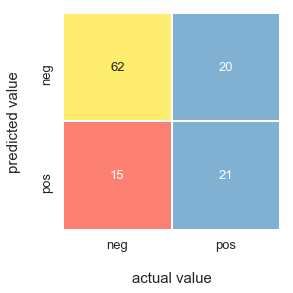

In [27]:
def show_confusion_matrix(y_test, y_pred, palette="Set3"):
    ## see: https://www.geeksforgeeks.org/confusion-matrix-machine-learning/
    ##      https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html
    ##      https://classeval.wordpress.com/introduction/basic-evaluation-measures/
    matrix = confusion_matrix(y_test, y_pred)

    colors = sns.color_palette(palette) # set the colors to use for heatmap
    # print(colors.as_hex()) # uncomment this to see color palette

    ax = sns.heatmap(matrix, square=True, annot=True, fmt='d', 
                     cbar=False, cmap=colors, vmin=-1, annot_kws={"size":13}, linewidths=1.0)

    # set labels on figure
    ax.set_xticklabels(labels=["neg","pos"], fontsize=13)
    ax.set_yticklabels(labels=["neg","pos"], fontsize= 13)
    plt.xlabel("\nactual value", fontsize=15)
    plt.ylabel("predicted value\n", fontsize=15)
    plt.show()

## show confustion matrix for dtree
show_confusion_matrix(y_test, y_pred_tree)

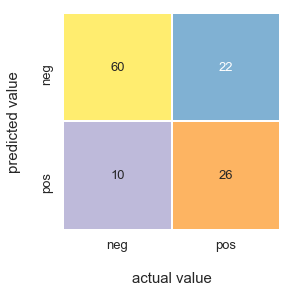

In [28]:
## show confustion matrix for dtree_pruned
show_confusion_matrix(y_test, y_pred_pruned)

As an exercise, use one of the above confusion matrices to compute the recall and precision of either the full or pruned decision tree.
* Recall: TP / (TP + FN)
* Precision: TP / (TP + FP)

## Random forest
Random forest classifers are similar to decision trees in that they use hierarchical structures to split the dataset based on features. However, unlike decision trees, these classifiers use muliple decision trees (a "forest") in classification process.

The random forest algorithm consists of four general steps:
* Select random samples from a given dataset.
* Construct a decision tree for each sample and get a prediction result from each decision tree.
* Perform a vote for each predicted result.
* Select the prediction result with the most votes as the final prediction.

<img width="450px" src="images/random_forest_voting.jpg" />

**Advantages**
* Random forests is considered as a highly accurate and robust method because of the number of decision trees participating in the process.
* It does not suffer from the overfitting problem. The main reason is that it takes the average of all the predictions, which cancels out the biases.
* The algorithm can be used in both classification and regression problems.
* Random forests can also handle missing values. There are two ways to handle these: using median values to replace continuous variables, and computing the proximity-weighted average of missing values.
* You can get the relative feature importance, which helps in selecting the most contributing features for the classifier.

**Disadvantages**
* Random forests is slow in generating predictions because it has multiple decision trees. Whenever it makes a prediction, all the trees in the forest have to make a prediction for the same given input and then perform voting on it. This whole process is time-consuming.
* The model is difficult to interpret compared to a decision tree, where you can easily make a decision by following the path in the tree.



## Implementing random forest
Like decision trees, building and fitting a random forest classifier is a straightforward task  in scikit-learn. First, we define a random forest classifier variable, and, second, we train the classifier by calling the `fit` method.

In [29]:
## build and fit random forest classifier
rfc = RandomForestClassifier(n_estimators=250)
rfc.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=250, n_jobs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

## Evaluating random forest
We can evaluate the our random forest classifier by calculating the accuracy, recall, precision, and F1 scores.

In [30]:
y_pred_forest = rfc.predict(X_test)
accuracy_score(y_test, y_pred_forest)

0.7372881355932204

In [31]:
recall_score(y_test, y_pred_forest)

0.5833333333333334

In [32]:
precision_score(y_test, y_pred_forest)

0.5675675675675675

In [33]:
f1_score(y_test, y_pred_forest)

0.5753424657534246

As before, we can display the `confusion_matrix` of our classifier.

In [34]:
## get values for confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_forest).ravel()
print((tn, fp, fn, tp))

(66, 16, 15, 21)


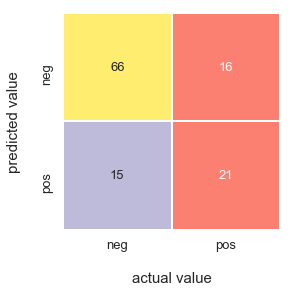

In [35]:
## show confusion matrix for random forest
show_confusion_matrix(y_test, y_pred_forest)

## Feature ranking
In addition to evaluating the random forest classifier, it is sometimes helpful to see how important each of the features were in arriving at final predictions. If we notice that a feature is of little importance, we can eliminate it from our training dataset in order to gain efficiency.

When building a random forest classifier, scikit-learn returns a variable named `feature_importances_`.

In [36]:
## find important features
rfc.feature_importances_

array([0.09892923, 0.13019403, 0.12324381, 0.12941527, 0.25433136,
       0.07022444, 0.09527094, 0.09839092])

The raw output is a little difficult to interpret. So, we will put the output in a Pandas Series.

In [37]:
feature_imp = \
    pds.Series(rfc.feature_importances_, index=feature_cols).sort_values(ascending=False)

feature_imp

Glucose                     0.254331
Insulin                     0.130194
Age                         0.129415
BMI                         0.123244
Pregnancies                 0.098929
SkinThickness               0.098391
DiabetesPedigreeFunction    0.095271
BloodPressure               0.070224
dtype: float64

We can also visualize the features importances using a seaborn barplot.

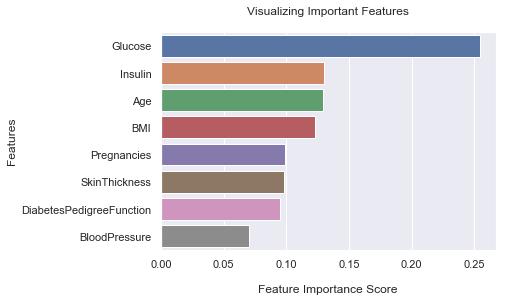

In [38]:
## visualize important features
%matplotlib inline

# Creating a bar plot
sns.barplot(x=feature_imp, y=feature_imp.index)

# Add labels to your graph
plt.xlabel('\nFeature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features\n")

plt.show()

## Wrapping up
In this module, we have covered a numbered of important concepts related to decision tree and random forest classifiers, such as:
* Inspecting the data using correlation matrices and histograms
* Building training and test datasets
* Defining decision tree and random forest classifiers using scikit-learn and predicting target classes
* Evaluating classifiers using a confusion matrix and calculating the accuracy, precision, recall, and F1 scores.
* Inspecting the importance of features in our classifier